In [3]:
import numpy as np
import xarray as xr
import earthkit.data
import earthkit.plots
import earthkit.regrid
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import xesmf as xe

/home/ubuntu/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


ModuleNotFoundError: No module named 'ESMF'

In [86]:
request = {
     'activity': 'CMIP6',
     'class': 'd1',
     'dataset': 'climate-dt',
     'date': '19900201',
     'experiment': 'hist',
     'expver': '0001',
     'generation': '1',
     'levtype': 'o2d',
     'model': 'IFS-NEMO',
     'param': '263001',
     'realization': '1',
     'resolution': 'standard',
     'stream': 'clte',
     'time': '0000', # '0100/0200/0300/0400/0500/0600'
     'type': 'fc'
 }

In [87]:
data = earthkit.data.from_source("polytope", "destination-earth", request, address="polytope.lumi.apps.dte.destination-earth.eu", stream=False)

2025-01-20 15:58:11 - INFO - Key read from /home/ubuntu/.polytopeapirc
2025-01-20 15:58:11 - INFO - Sending request...
{'request': 'activity: CMIP6\n'
            'class: d1\n'
            'dataset: climate-dt\n'
            "date: '19900201'\n"
            'experiment: hist\n'
            "expver: '0001'\n"
            "generation: '1'\n"
            'levtype: o2d\n'
            'model: IFS-NEMO\n'
            "param: '263001'\n"
            "realization: '1'\n"
            'resolution: standard\n'
            'stream: clte\n'
            "time: '0000'\n"
            'type: fc\n',
 'verb': 'retrieve'}
2025-01-20 15:58:11 - INFO - Polytope user key found in session cache for user ubuntu
2025-01-20 15:58:11 - INFO - Request accepted. Please poll ./e00174b1-791e-4092-ac17-11c1693511ec for status
2025-01-20 15:58:11 - INFO - Polytope user key found in session cache for user ubuntu
2025-01-20 15:58:11 - INFO - Checking request status (./e00174b1-791e-4092-ac17-11c1693511ec)...
2025-01-20 1

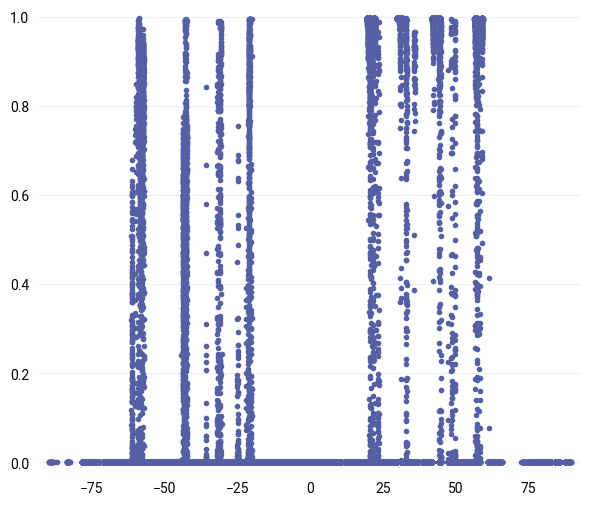

In [88]:
ds=data.to_xarray()
plt.plot(ds.latitude,ds.avg_siconc,'.')

In [69]:
out_grid = {"grid": [0.5,0.5]}
#out_grid={"grid": "eORCA025_T"}
r = earthkit.regrid.interpolate(data, out_grid=out_grid, method="linear")
#r = earthkit.regrid.interpolate(data, out_grid=out_grid, method="nearest-neighbour")

d = r.data()
lat = d[0]
lon = d[1]
vals = d[2:]
lat.shape, lon.shape, vals.shape

((361, 720), (361, 720), (1, 361, 720))

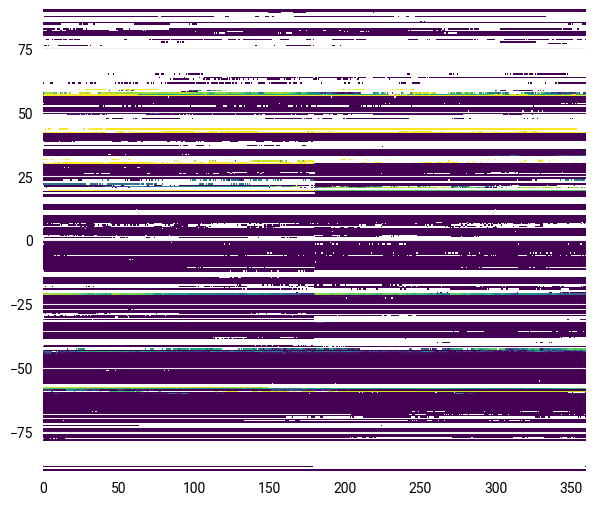

In [76]:
ds = r.to_xarray()
plt.pcolormesh(lon,lat,vals.squeeze())

In [ ]:
#ds.avg_so.isel(levelist=0,forecast_reference_time=0).plot(x='longitude',y='latitude')
ds.avg_siconc.plot()#x='longitude',y='latitude')